In [1]:
# for dataframes and data anlysis
import pandas as pd
import numpy as np
# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# make pandas display all columns of data in a dataframe
pd.set_option('display.max_columns', None)

In [3]:
#import the advanced QB data from fantasy points
#first let's make a dictionary of the files that include the year the data is from
files = {
    2021: 'C:\\Users\\SpeeJ\\OneDrive\\Desktop\\Fantasy_Points_Data\\FP_QB_Data\\Advanced_QB_Data_2021.csv',
    2022: 'C:\\Users\\SpeeJ\\OneDrive\\Desktop\\Fantasy_Points_Data\\FP_QB_Data\\Advanced_QB_Data_2022.csv',
    2023: 'C:\\Users\\SpeeJ\\OneDrive\\Desktop\\Fantasy_Points_Data\\FP_QB_Data\\Advanced_QB_Data_2023.csv',
    2024: 'C:\\Users\\SpeeJ\\OneDrive\\Desktop\\Fantasy_Points_Data\\FP_QB_Data\\Advanced_QB_Data_2024.csv',
    2025: 'C:\\Users\\SpeeJ\\OneDrive\\Desktop\\Fantasy_Points_Data\\FP_QB_Data\\Advanced_QB_Data_2025.csv'
}

#create an empty list to store the dataframes
Advanced_QB_Data_List = []

#loop through the dictionary to read and tag each file
for year, file_name in files.items():
    df = pd.read_csv(file_name)
    df['Season'] = year  # Add a column to indicate the season
    Advanced_QB_Data_List.append(df)

#concatenate all the dataframes into one
Advanced_QB_Data = pd.concat(Advanced_QB_Data_List, ignore_index=True)

#drop the ranking column since it is not needed for our analysis
Advanced_QB_Data.drop(columns=['Rank'], axis=1, inplace=True)

#verify the data
print(Advanced_QB_Data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 58 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          395 non-null    object 
 1   Team          395 non-null    object 
 2   POS           395 non-null    object 
 3   G             395 non-null    int64  
 4   Season        395 non-null    int64  
 5   DB            395 non-null    int64  
 6   ATT           395 non-null    int64  
 7   CMP           395 non-null    int64  
 8   CMP %         381 non-null    float64
 9   YDS           395 non-null    int64  
 10  YDS/G         395 non-null    float64
 11  YPA           381 non-null    float64
 12  TD            395 non-null    int64  
 13  INT           395 non-null    int64  
 14  1D            395 non-null    int64  
 15  RATE          384 non-null    float64
 16  SACK          395 non-null    int64  
 17  SACK %        345 non-null    float64
 18  SK YDS        395 non-null    

In [4]:
#sort out QBs that haven't attemtped enough passes in a season to be considered a starter
pass_attempts_threshold = 200
Advanced_QB_Data = Advanced_QB_Data[Advanced_QB_Data['ATT'] >= pass_attempts_threshold]
#check the data again to make sure the filter worked
Advanced_QB_Data.info()
# we go from 395 QBs to 176 QBs, so we have 176 QBs that are considered starters based on our criteria

<class 'pandas.core.frame.DataFrame'>
Index: 176 entries, 0 to 354
Data columns (total 58 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          176 non-null    object 
 1   Team          176 non-null    object 
 2   POS           176 non-null    object 
 3   G             176 non-null    int64  
 4   Season        176 non-null    int64  
 5   DB            176 non-null    int64  
 6   ATT           176 non-null    int64  
 7   CMP           176 non-null    int64  
 8   CMP %         176 non-null    float64
 9   YDS           176 non-null    int64  
 10  YDS/G         176 non-null    float64
 11  YPA           176 non-null    float64
 12  TD            176 non-null    int64  
 13  INT           176 non-null    int64  
 14  1D            176 non-null    int64  
 15  RATE          176 non-null    float64
 16  SACK          176 non-null    int64  
 17  SACK %        176 non-null    float64
 18  SK YDS        176 non-null    int64

In [5]:
#rename the rushing yards and tds columns to make them more clear
Advanced_QB_Data.rename(columns={
    'YDS': 'P_YDS', 
    'TD': 'P_TDs',
    'YDS.1': 'R_YDS',
    'TD.1': 'R_TDs'
}, inplace=True)

#add the columns for total yards and total touchdowns and Passing TDs per Attempt
Advanced_QB_Data['Total_Yards'] = Advanced_QB_Data['P_YDS'] + Advanced_QB_Data['R_YDS']
Advanced_QB_Data['Total_TDs'] = Advanced_QB_Data['P_TDs'] + Advanced_QB_Data['R_TDs']
Advanced_QB_Data['P_TDs_Per_Att'] = Advanced_QB_Data['P_TDs'] / Advanced_QB_Data['ATT']

#get another QB metric by dividing QB SK by SACK to get the percentage of sacks that are the QBs fault
Advanced_QB_Data['QB SK %'] = Advanced_QB_Data['QB SK'] / Advanced_QB_Data['SACK']

#let's get the percentiles for each statistic as-well to see how each QB compares to the rest of the league in each category  
#from seasons from 2021 to 2025
#create a list of columns to get the percentiles
columns_to_get_percentiles = ['P_YDS', 'P_TDs', 'YPA', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att',
                              'SACK', 'SACK %', 'TTT','TTP', 'TTSK', 'TTSC','QB SK', 'QB SK %', 'QBP', 'PRESS %', 
                              'PRESS SK %', 'PrROE', 'CHK %', 'TA']
#calculate the percentiles for each of these columns
for col in columns_to_get_percentiles:
    Advanced_QB_Data[f'{col}_percentile'] = Advanced_QB_Data[col].rank(pct=True) * 100

In [6]:
#let's get the average the stats for an average MVP QB from 2021 to 2025
#make a list of the nfl mvps from 2021 to 2025
MVPs_dict = {
    2021: 'Aaron Rodgers',
    2022: 'Patrick Mahomes',
    2023: 'Lamar Jackson',
    2024: 'Josh Allen',
    2025: 'Matthew Stafford'
}

#now lets filter the Advanced_QB_Data to only include the MVPs
MVP_QB_Data = Advanced_QB_Data[Advanced_QB_Data.apply(lambda row: row['Name'] == MVPs_dict.get(row['Season']), axis=1)].copy()
#verify the data
MVP_QB_Data

,Name,Team,POS,G,Season,DB,ATT,CMP,CMP %,P_YDS,YDS/G,YPA,P_TDs,INT,1D,RATE,SACK,SACK %,SK YDS,ANY/A,SCRM,R_YDS,R_TDs,CPOE,aDOT,AY,Deep Throw %,Deep Throw,YAC %,ADJ CMP %,1Read %,ACC %,CATCH %,OFF %,HERO %,TWT %,EZATT,DROP %,DROP YDS,TTT,TTP,TTSK,TTSC,QB SK,QBP,PRESS %,PRESS SK %,PrROE,CHK %,RPO %,TA,BAT,SPK,FP/DB,FP/OPP,FP/G,FP,OPP,Total_Yards,Total_TDs,P_TDs_Per_Att,QB SK %,P_YDS_percentile,P_TDs_percentile,YPA_percentile,R_YDS_percentile,R_TDs_percentile,Total_Yards_percentile,Total_TDs_percentile,P_TDs_Per_Att_percentile,SACK_percentile,SACK %_percentile,TTT_percentile,TTP_percentile,TTSK_percentile,TTSC_percentile,QB SK_percentile,QB SK %_percentile,QBP_percentile,PRESS %_percentile,PRESS SK %_percentile,PrROE_percentile,CHK %_percentile,TA_percentile
9,Aaron Rodgers,GB,QB,16,2021,578,531,366,68.9,4115,257.2,7.75,37,4,213,111.9,30,5.2,188,8.00,17,111,2,6.0,5.5,2742,12.2,65,51.0,75.9,70.6,51.2,77.0,16.2,8.5,1.9,45,2.1,11,2.42,2.57,3.8,5.6,13,155,26.8,19.4,-2.44,7.5,6.1,19,8,3,0.58,0.57,21.1,337.3,594,4226,39,0.069680,0.433333,80.681818,94.602273,82.954545,40.909091,84.943182,76.704545,95.170455,97.159091,51.136364,30.965909,10.795455,70.170455,76.704545,97.413793,91.761364,95.454545,42.045455,9.659091,52.272727,14.204545,30.965909,55.965909
78,Patrick Mahomes,KC,QB,17,2022,720,648,435,67.1,5250,308.8,8.10,41,12,272,105.2,26,3.6,188,7.93,46,346,4,7.6,6.0,3599,8.3,54,53.0,80.0,64.5,51.9,77.0,14.2,4.9,3.2,36,5.7,300,2.69,2.66,3.4,4.8,7,246,34.2,10.6,1.38,5.6,5.7,41,8,0,0.60,0.58,25.3,429.4,735,5596,45,0.063272,0.269231,99.431818,97.443182,92.613636,84.659091,98.295455,100.000000,99.431818,92.045455,33.522727,4.829545,76.420455,87.500000,30.681818,54.310345,50.284091,62.500000,94.034091,48.863636,5.681818,40.340909,8.806818,98.579545
175,Lamar Jackson,BLT,QB,16,2023,560,457,307,67.2,3678,229.9,8.05,24,7,167,102.7,37,6.6,218,7.34,66,440,0,5.2,9.0,3881,13.3,61,48.9,77.4,68.9,50.5,77.7,16.2,5.9,2.4,31,5.5,286,2.77,2.69,4.0,4.9,10,208,37.1,17.8,6.21,7.0,7.5,16,9,1,0.61,0.54,21.5,344.2,642,4118,24,0.052516,0.270270,62.500000,67.613636,91.193182,98.011364,25.852273,70.454545,63.920455,78.409091,74.431818,61.363636,86.079545,91.193182,86.647727,61.206897,75.852273,63.068182,77.556818,71.875000,42.613636,73.863636,21.022727,44.034091
254,Josh Allen,BUF,QB,17,2024,540,483,307,63.6,3731,219.5,7.72,28,6,173,101.4,14,2.6,63,7.96,43,383,3,-0.4,8.6,3863,14.1,68,56.0,72.4,56.7,54.5,71.6,19.0,7.5,2.1,32,3.3,207,2.64,2.45,3.6,4.4,4,175,32.4,8.0,0.51,8.5,5.0,24,9,1,0.72,0.65,22.8,387.0,599,4114,31,0.057971,0.285714,65.909091,81.250000,81.818182,90.340909,94.602273,69.886364,85.511364,84.659091,5.965909,0.568182,65.056818,34.659091,54.261364,25.862069,23.295455,67.613636,53.693182,40.340909,0.568182,33.806818,53.409091,75.000000
318,Matthew Stafford,LA,QB,17,2025,627,597,388,65.0,4707,276.9,7.88,46,8,236,109.2,23,3.7,150,8.25,7,22,0,3.4,9.4,5277,13.6,81,40.8,74.9,68.0,56.1,76.2,16.2,6.7,2.5,52,6.0,287,2.56,2.57,3.4,4.8,3,187,29.8,12.3,-2.74,8.4,2.1,19,5,3,0.58,0.56,21.3,361.4,649,4729,46,0.077052,0.130435,95.454545,100.000000,85.227273,6.534091,25.852273,93.181818,100.000000,99.431818,23.863636,6.534091,46.022727,70.170455,30.681818,54.310345,15.340909,16.761364,65.625000,25.852273,10.795455,13.068182,51.136364,55.965909


In [7]:
#let's seperate the counting statistics for these MVPs
MVP_Counting_Stats = MVP_QB_Data[['P_YDS', 'P_TDs', 'INT', 'YPA', 'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
#now let's get the average stats for these MVPs 
MVP_Average_Counting_Stats = MVP_Counting_Stats.mean()
#finally let's see the average stats for an MVP QB from 2021 to 2025
MVP_Average_Counting_Stats

P_YDS            4296.200000
P_TDs              35.200000
INT                 7.400000
YPA                 7.900000
ATT               543.200000
R_YDS             260.400000
R_TDs               1.800000
Total_Yards      4556.600000
Total_TDs          37.000000
P_TDs_Per_Att       0.064098
dtype: float64

In [8]:
Drake_Maye_Counting_Sats = Advanced_QB_Data[(Advanced_QB_Data['Name'] == 'Drake Maye') & (Advanced_QB_Data['Season'] == 2025)][['P_YDS', 'P_TDs', 'INT', 'YPA', 'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
Drake_Maye_Counting_Sats_Series = Drake_Maye_Counting_Sats.iloc[0]
Drake_Maye_Counting_Sats_Series

P_YDS            4394.000000
P_TDs              31.000000
INT                 8.000000
YPA                 8.930000
ATT               492.000000
R_YDS             429.000000
R_TDs               3.000000
Total_Yards      4823.000000
Total_TDs          34.000000
P_TDs_Per_Att       0.063008
Name: 321, dtype: float64

In [9]:
#combine the two series to use for a comparison column chart
comparison_df = pd.DataFrame({
    'MVP Average (2021-25)': MVP_Average_Counting_Stats,
    'Drake Maye (2025)': Drake_Maye_Counting_Sats_Series
})

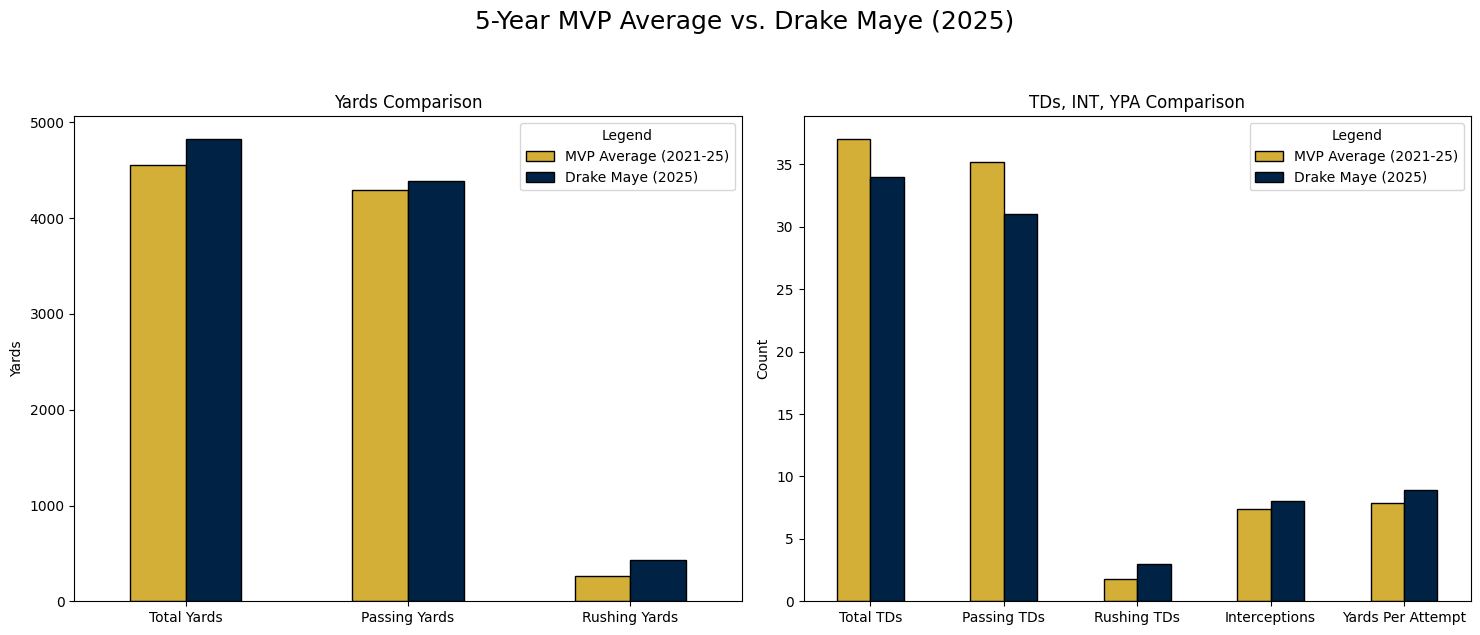

In [10]:
#define the metrics that will go on each plot
yards_metrics = ['Total_Yards', 'P_YDS', 'R_YDS']
tds_int_ypa_metrics = ['Total_TDs', 'P_TDs', 'R_TDs', 'INT', 'YPA']

#create subplots for (1 row, 2 columns  
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#yards plot
comparison_df.loc[yards_metrics].plot(kind='bar', ax=axes[0], color=['#D4AF37', '#002244'], edgecolor='black')
axes[0].set_title('Yards Comparison')
axes[0].set_ylabel('Yards')
axes[0].set_xticklabels(['Total Yards', 'Passing Yards', 'Rushing Yards'], rotation=0, ha='center')
axes[0].legend(title='Legend')

#tds_int_ypa_metrics plot
comparison_df.loc[tds_int_ypa_metrics].plot(kind='bar', ax=axes[1], color=['#D4AF37', '#002244'], edgecolor='black')
axes[1].set_title('TDs, INT, YPA Comparison')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Total TDs', 'Passing TDs', 'Rushing TDs', 'Interceptions', 'Yards Per Attempt'], rotation=0, ha='center')
axes[1].legend(title='Legend')

# Final formatting
plt.suptitle('5-Year MVP Average vs. Drake Maye (2025)', fontsize=18, y=1.05)
plt.tight_layout()

plt.show()

In [11]:
#now time to look at Justin Herbert's 2025 stats to disect them thouroughly to see comparable seasons
#judging by his pressure stats
Justin_Herbert_2025 = Advanced_QB_Data[(Advanced_QB_Data['Name'] == 'Justin Herbert') & (Advanced_QB_Data['Season'] == 2025)].copy()
#verify the data    
Justin_Herbert_2025

,Name,Team,POS,G,Season,DB,ATT,CMP,CMP %,P_YDS,YDS/G,YPA,P_TDs,INT,1D,RATE,SACK,SACK %,SK YDS,ANY/A,SCRM,R_YDS,R_TDs,CPOE,aDOT,AY,Deep Throw %,Deep Throw,YAC %,ADJ CMP %,1Read %,ACC %,CATCH %,OFF %,HERO %,TWT %,EZATT,DROP %,DROP YDS,TTT,TTP,TTSK,TTSC,QB SK,QBP,PRESS %,PRESS SK %,PrROE,CHK %,RPO %,TA,BAT,SPK,FP/DB,FP/OPP,FP/G,FP,OPP,Total_Yards,Total_TDs,P_TDs_Per_Att,QB SK %,P_YDS_percentile,P_TDs_percentile,YPA_percentile,R_YDS_percentile,R_TDs_percentile,Total_Yards_percentile,Total_TDs_percentile,P_TDs_Per_Att_percentile,SACK_percentile,SACK %_percentile,TTT_percentile,TTP_percentile,TTSK_percentile,TTSC_percentile,QB SK_percentile,QB SK %_percentile,QBP_percentile,PRESS %_percentile,PRESS SK %_percentile,PrROE_percentile,CHK %_percentile,TA_percentile
326,Justin Herbert,LAC,QB,16,2025,615,512,340,66.4,3727,232.9,7.28,26,13,175,94.1,54,8.8,301,5.94,49,439,1,4.9,8.2,3948,12.1,62,44.9,78.3,64.3,61.5,77.3,14.5,5.1,2.3,39,6.1,248,2.6,2.44,3.4,4.4,12,267,43.4,20.2,14.37,7.0,2.6,20,8,0,0.49,0.47,18.9,301.9,649,4166,27,0.050781,0.222222,65.056818,77.272727,61.931818,97.159091,64.772727,73.295455,76.136364,71.590909,96.022727,87.215909,55.397727,29.829545,30.681818,25.862069,87.5,45.454545,100.0,94.886364,60.511364,96.590909,21.022727,61.079545


In [12]:
#let's look at the average MVPs pressure stats to compare to Justin Herbert's 2025 pressure stats
MVP_Pressure_Stats = MVP_QB_Data[['SACK', 'SACK %', 'TTT','TTP','QB SK', 'QBP', 'PRESS %', 'PRESS SK %',
                                  'PrROE']].copy()
#get the average pressure stats for the MVPs
MVP_Average_Pressure_Stats = MVP_Pressure_Stats.mean()
#now let's look at the average MVP pressure stats
MVP_Average_Pressure_Stats

SACK           26.000
SACK %          4.340
TTT             2.616
TTP             2.588
QB SK           7.400
QBP           194.200
PRESS %        32.060
PRESS SK %     13.620
PrROE           0.584
dtype: float64

In [50]:
#now let's look at Herbert's 2025 pressure stats to compare to the average MVP pressure stats
Justin_Herbert_2025_Pressure_Stats = Justin_Herbert_2025[['SACK', 'SACK_percentile', 'SACK %', 'SACK %_percentile', 'TTT', 'TTT_percentile',
                                                          'TTP', 'TTP_percentile', 'TTSK', 'TTSK_percentile', 'QB SK', 'QB SK_percentile', 'QB SK %', 'QB SK %_percentile', 
                                                          'QBP', 'QBP_percentile', 'PRESS %', 'PRESS %_percentile', 'PRESS SK %', 'PRESS SK %_percentile', 
                                                          'PrROE', 'PrROE_percentile', 'CHK %', 'CHK %_percentile', 'TA', 'TA_percentile']].copy()
Justin_Herbert_2025_Pressure_Stats

,SACK,SACK_percentile,SACK %,SACK %_percentile,TTT,TTT_percentile,TTP,TTP_percentile,TTSK,TTSK_percentile,QB SK,QB SK_percentile,QB SK %,QB SK %_percentile,QBP,QBP_percentile,PRESS %,PRESS %_percentile,PRESS SK %,PRESS SK %_percentile,PrROE,PrROE_percentile,CHK %,CHK %_percentile,TA,TA_percentile
326,54,96.022727,8.8,87.215909,2.6,55.397727,2.44,29.829545,3.4,30.681818,12,87.5,0.222222,45.454545,267,100.0,43.4,94.886364,20.2,60.511364,14.37,96.590909,7.0,21.022727,20,61.079545


In [ ]:
#let's compare these to Drake Mayes 2025 pressure stats
Drake_Maye_2025 = Advanced_QB_Data[(Advanced_QB_Data['Name'] == 'Drake Maye') & (Advanced_QB_Data['Season'] == 2025)].copy()
Drake_Maye_2025_Pressure_Stats = Drake_Maye_2025[['SACK', 'SACK_percentile', 'SACK %', 'SACK %_percentile', 'TTT', 'TTT_percentile',
                                                          'TTP', 'TTP_percentile', 'TTSK', 'TTSK_percentile', 'QB SK', 'QB SK_percentile', 'QB SK %', 'QB SK %_percentile', 
                                                          'QBP', 'QBP_percentile', 'PRESS %', 'PRESS %_percentile', 'PRESS SK %', 'PRESS SK %_percentile', 
                                                          'PrROE', 'PrROE_percentile', 'CHK %', 'CHK %_percentile', 'TA', 'TA_percentile']].copy()
Drake_Maye_2025_Pressure_Stats

,SACK,SACK_percentile,SACK %,SACK %_percentile,TTT,TTT_percentile,TTP,TTP_percentile,TTSK,TTSK_percentile,QB SK,QB SK_percentile,QB SK %,QB SK %_percentile,QBP,QBP_percentile,PRESS %,PRESS %_percentile,PRESS SK %,PRESS SK %_percentile,PrROE,PrROE_percentile,CHK %,CHK %_percentile,TA,TA_percentile
321,47,92.045455,7.8,76.136364,2.82,90.909091,2.68,90.056818,4.0,86.647727,23,100.0,0.489362,99.431818,266,98.863636,44.3,97.159091,17.7,41.477273,12.57,94.318182,9.3,67.897727,20,61.079545


<Figure size 800x600 with 0 Axes>

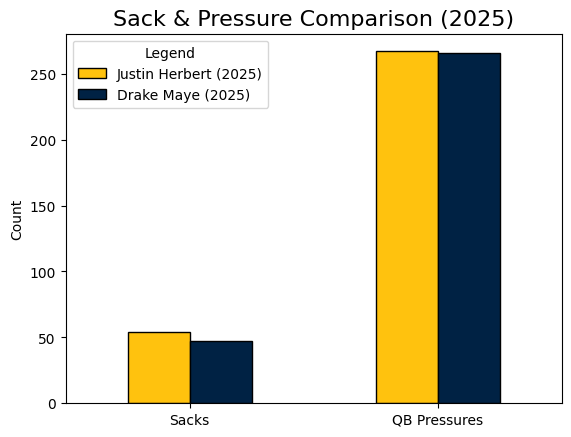

In [15]:
#make a column chart of the sack and pressure stats for both QBs
sack_and_pressure_stats_comp_df = pd.DataFrame({
    'Justin Herbert (2025)': Justin_Herbert_2025_Pressure_Stats[['SACK', 'QBP']].iloc[0],
    'Drake Maye (2025)': Drake_Maye_2025_Pressure_Stats[['SACK', 'QBP']].iloc[0]
})

#make a figure
plt.figure(figsize=(8, 6))
sack_and_pressure_stats_comp_df.plot(kind='bar', color=['#FFC20E', '#002244'], edgecolor='black')
plt.title('Sack & Pressure Comparison (2025)', fontsize=16)
plt.ylabel('Count')
plt.xticks([0, 1], labels=['Sacks', 'QB Pressures'], rotation=0, ha='center')
plt.legend(title='Legend')

plt.show()

Text(0.5, 1.05, 'Justin Herbert vs. Drake Maye Time to Throw/Pressure Stats Comparison (2025)')

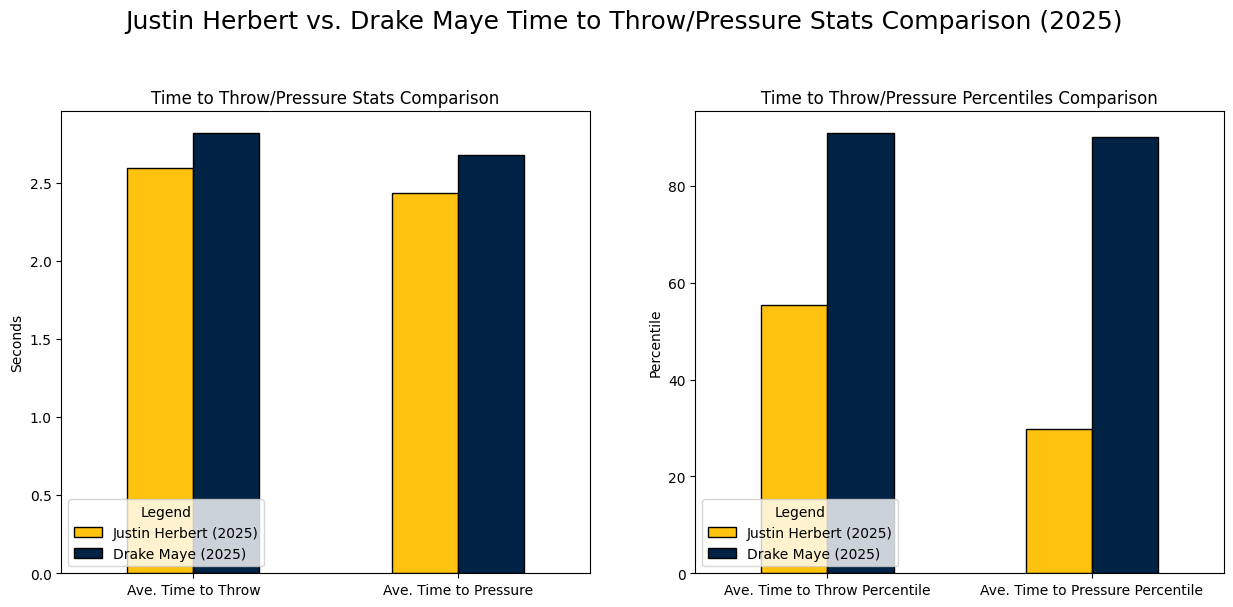

In [16]:
#make a column chart comparing these pressure stats between Herbert and Maye
time_to_pressure_stats_comp_df = pd.DataFrame({
    'Justin Herbert (2025)': Justin_Herbert_2025_Pressure_Stats[['TTT','TTP']].iloc[0],
    'Drake Maye (2025)': Drake_Maye_2025_Pressure_Stats[['TTT','TTP']].iloc[0]
})
time_to_pressure_percentiles_comp_df = pd.DataFrame({
    'Justin Herbert (2025)': Justin_Herbert_2025_Pressure_Stats[['TTT_percentile','TTP_percentile']].iloc[0],
    'Drake Maye (2025)': Drake_Maye_2025_Pressure_Stats[['TTT_percentile','TTP_percentile']].iloc[0]
})

#make the figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
#time to pressure stats comparison
time_to_pressure_stats_comp_df.plot(kind='bar', ax=axes[0], color=['#FFC20E', '#002244'], edgecolor='black')
axes[0].set_title('Time to Throw/Pressure Stats Comparison')
axes[0].set_ylabel('Seconds')
axes[0].set_xticklabels(['Ave. Time to Throw', 'Ave. Time to Pressure'], rotation=0, ha='center')
axes[0].legend(title='Legend', loc='lower left')
#time to pressure percentiles comparison
time_to_pressure_percentiles_comp_df.plot(kind='bar', ax=axes[1], color=['#FFC20E', '#002244'], edgecolor='black')
axes[1].set_title('Time to Throw/Pressure Percentiles Comparison')
axes[1].set_ylabel('Percentile')
axes[1].set_xticklabels(['Ave. Time to Throw Percentile', 'Ave. Time to Pressure Percentile'], rotation=0, ha='center')
axes[1].legend(title='Legend', loc='lower left')
# Final formatting
plt.suptitle('Justin Herbert vs. Drake Maye Time to Throw/Pressure Stats Comparison (2025)', fontsize=18, y=1.05)

In [17]:
#let's see the upper and lower ranges of these statistics
print(Advanced_QB_Data[['SACK', 'SACK_percentile', 'SACK %', 'SACK %_percentile', 'TTT', 'TTT_percentile',
                                                          'TTP', 'TTP_percentile', 'QB SK', 'QB SK_percentile', 'QB SK %', 'QB SK %_percentile', 
                                                          'QBP', 'QBP_percentile', 'PRESS %', 'PRESS %_percentile', 'PRESS SK %', 'PRESS SK %_percentile', 
                                                          'PrROE', 'PrROE_percentile', 'CHK %']].describe())

             SACK  SACK_percentile      SACK %  SACK %_percentile         TTT  \
count  176.000000       176.000000  176.000000         176.000000  176.000000   
mean    30.806818        50.284091    6.424432          50.284091    2.593182   
std     11.081885        28.929519    2.015688          28.942923    0.161426   
min      8.000000         0.852273    2.600000           0.568182    2.200000   
25%     23.000000        23.863636    5.000000          25.852273    2.500000   
50%     30.000000        51.136364    6.100000          51.136364    2.580000   
75%     38.000000        77.272727    7.725000          74.857955    2.682500   
max     68.000000       100.000000   12.500000         100.000000    3.080000   

       TTT_percentile         TTP  TTP_percentile       QB SK  \
count      176.000000  176.000000      176.000000  176.000000   
mean        50.284091    2.510682       50.284091    7.392045   
std         28.938222    0.129930       28.936102    4.125149   
min       

In [18]:
#get the 85th percentile for these pressure stats to limit outliers and get an accurate picture of a rnage of QB
pressure_stats = ['SACK', 'SACK %', 'TTT', 'TTP', 'QB SK', 'QB SK %', 'QBP', 
                  'PRESS %', 'PRESS SK %', 'PrROE','CHK %']
pressure_stats_85th_percentiles = Advanced_QB_Data[pressure_stats].quantile(0.85)
pressure_stats_85th_percentiles

SACK           41.000000
SACK %          8.575000
TTT             2.760000
TTP             2.650000
QB SK          11.750000
QB SK %         0.365909
QBP           224.750000
PRESS %        39.200000
PRESS SK %     24.575000
PrROE           8.402500
CHK %          10.950000
Name: 0.85, dtype: float64

In [19]:
#get the 80th percentile for these pressure stats to limit outliers and get an accurate picture of a rnage of QB
pressure_stats = ['SACK', 'SACK %', 'TTT', 'TTP', 'QB SK', 'QB SK %', 'QBP', 
                  'PRESS %', 'PRESS SK %', 'PrROE','CHK %']
pressure_stats_80th_percentiles = Advanced_QB_Data[pressure_stats].quantile(0.8)
pressure_stats_80th_percentiles

SACK           39.000000
SACK %          8.300000
TTT             2.710000
TTP             2.620000
QB SK          10.000000
QB SK %         0.333333
QBP           215.000000
PRESS %        38.300000
PRESS SK %     23.400000
PrROE           7.310000
CHK %          10.500000
Name: 0.8, dtype: float64

In [20]:
#get the 75th percentile for these pressure stats to limit outliers and get an accurate picture of a rnage of QB
pressure_stats = ['SACK', 'SACK %', 'TTT', 'TTP', 'QB SK', 'QB SK %', 'QBP', 
                  'PRESS %', 'PRESS SK %', 'PrROE','CHK %']
pressure_stats_75th_percentiles = Advanced_QB_Data[pressure_stats].quantile(0.75)
pressure_stats_75th_percentiles

SACK           38.000000
SACK %          7.725000
TTT             2.682500
TTP             2.590000
QB SK          10.000000
QB SK %         0.316388
QBP           203.000000
PRESS %        37.725000
PRESS SK %     22.100000
PrROE           6.295000
CHK %          10.000000
Name: 0.75, dtype: float64

In [21]:
#get the 40th percentile for these pressure stats to limit outliers and get an accurate picture of a rnage of QB
pressure_stats = ['SACK', 'SACK %', 'TTT', 'TTP', 'QB SK', 'QB SK %', 'QBP', 
                  'PRESS %', 'PRESS SK %', 'PrROE','CHK %']
pressure_stats_40th_percentiles = Advanced_QB_Data[pressure_stats].quantile(0.40)
pressure_stats_40th_percentiles

SACK           28.000000
SACK %          5.700000
TTT             2.540000
TTP             2.460000
QB SK           6.000000
QB SK %         0.206897
QBP           154.000000
PRESS %        32.400000
PRESS SK %     17.400000
PrROE           1.380000
CHK %           8.000000
Name: 0.4, dtype: float64

In [22]:
#get the 20th percentile for these pressure stats to limit outliers and get an accurate picture of a rnage of QB
pressure_stats = ['SACK', 'SACK %', 'TTT', 'TTP', 'QB SK', 'QB SK %', 'QBP', 
                  'PRESS %', 'PRESS SK %', 'PrROE','CHK %']
pressure_stats_20th_percentiles = Advanced_QB_Data[pressure_stats].quantile(0.2)
pressure_stats_20th_percentiles

SACK           22.000000
SACK %          4.700000
TTT             2.480000
TTP             2.410000
QB SK           3.000000
QB SK %         0.142857
QBP           116.000000
PRESS %        28.800000
PRESS SK %     14.600000
PrROE          -1.490000
CHK %           7.000000
Name: 0.2, dtype: float64

In [23]:
#let's look at the QBs who had pressure rates over expected of 7.3% or higher
High_PrROE_QBs = Advanced_QB_Data[Advanced_QB_Data['PrROE'] >= 7.3].copy()
#get the number of players that fall into this category
num_high_pressure_qbs = High_PrROE_QBs['Name'].count()
print("High PrROE QBs:", num_high_pressure_qbs)

#let's look at the seasons where QBs had pressure percentages over 38.3% or higher
High_Pressure_Percentage_QBs = Advanced_QB_Data[Advanced_QB_Data['PRESS %'] >= 38.3].copy()
#get the number of players that fall into this category
num_high_pressure_percentage_qbs = High_Pressure_Percentage_QBs['Name'].count()
print("High pressure percentage QBs:", num_high_pressure_percentage_qbs)

#let's look at the seasons where QBs had high sack percentages over 7.7%
High_Sack_Percentage_QBs = Advanced_QB_Data[Advanced_QB_Data['SACK %'] >= 7.7].copy()
#get the number of players that fall into this category
num_high_sack_percentage_qbs = High_Sack_Percentage_QBs['Name'].count()
print("High sack percentage QBs:", num_high_sack_percentage_qbs)

#let's look at QBs who were quickly pressured like Herbert with 2.46 seconds to 2.41 seconds to pressure
Quickly_Pressured_QBs = Advanced_QB_Data[(Advanced_QB_Data['TTT'] >= 2.41) & (Advanced_QB_Data['TTT'] <= 2.46)].copy()    
#get the number of players that fall into this category
num_quick_pressure_qbs = Quickly_Pressured_QBs['Name'].count()
print("Quickly pressured QBs:", num_quick_pressure_qbs)

#let's look at QBs who weren't quickly pressured like Mayre with 2.65 seconds or more
Not_Quickly_Pressured_QBs = Advanced_QB_Data[Advanced_QB_Data['TTT'] >= 2.65].copy()
#get the number of players that fall into this category
num_not_quick_pressure_qbs = Not_Quickly_Pressured_QBs['Name'].count()
print("Not quickly pressured QBs:", num_not_quick_pressure_qbs)

High PrROE QBs: 36
High pressure percentage QBs: 36
High sack percentage QBs: 47
Quickly pressured QBs: 17
Not quickly pressured QBs: 59


In [38]:
#now get the average counting stats for the QBs with high pressure percentages
High_Pressure_Percentage_QBs_Counting_Stats = High_Pressure_Percentage_QBs[['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
#get the average counting stats for these highly pressured QBs
High_Pressure_Percentage_QBs_Average_Counting_Stats = High_Pressure_Percentage_QBs_Counting_Stats.mean()
High_Pressure_Percentage_QBs_Average_Counting_Stats

P_YDS            2667.194444
YDS/G             199.125000
P_TDs              16.277778
INT                 8.805556
YPA                 6.835833
ATT               387.750000
R_YDS             236.361111
R_TDs               1.083333
Total_Yards      2903.555556
Total_TDs          17.361111
P_TDs_Per_Att       0.041395
dtype: float64

In [39]:
#now get the average counting stats for the QBs with high PrROE
High_PrROE_QBs_Counting_Stats = High_PrROE_QBs[['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
#get the average counting stats for these highly pressured QBs
High_PrROE_QBs_Average_Counting_Stats = High_PrROE_QBs_Counting_Stats.mean()
High_PrROE_QBs_Average_Counting_Stats

P_YDS            2516.277778
YDS/G             194.616667
P_TDs              15.027778
INT                 8.638889
YPA                 6.893056
ATT               360.972222
R_YDS             229.472222
R_TDs               1.138889
Total_Yards      2745.750000
Total_TDs          16.166667
P_TDs_Per_Att       0.040008
dtype: float64

In [40]:
#now get the average counting stats for the QBs with high sack percentages
High_Sack_Percentage_QBs_Counting_Stats = High_Sack_Percentage_QBs[['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
#get the average counting stats for these highly pressured QBs
High_Sack_Percentage_QBs_Average_Counting_Stats = High_Sack_Percentage_QBs_Counting_Stats.mean()
High_Sack_Percentage_QBs_Average_Counting_Stats

P_YDS            2640.425532
YDS/G             201.076596
P_TDs              15.212766
INT                 9.127660
YPA                 6.962766
ATT               376.787234
R_YDS             221.170213
R_TDs               0.914894
Total_Yards      2861.595745
Total_TDs          16.127660
P_TDs_Per_Att       0.039296
dtype: float64

In [41]:
#now get the average counting stats for the QBs with that were quickly pressured like Herbert
Quickly_Pressured_QBs_Counting_Stats = Quickly_Pressured_QBs[['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
#get the average counting stats for these highly pressured QBs
Quickly_Pressured_QBs_Average_Counting_Stats = Quickly_Pressured_QBs_Counting_Stats.mean()
Quickly_Pressured_QBs_Average_Counting_Stats

P_YDS            2707.470588
YDS/G             218.200000
P_TDs              16.411765
INT                 8.647059
YPA                 7.229412
ATT               371.705882
R_YDS              86.882353
R_TDs               0.352941
Total_Yards      2794.352941
Total_TDs          16.764706
P_TDs_Per_Att       0.042550
dtype: float64

In [48]:
#now get the average counting stats for the QBs with that were NOT quickly pressured like Maye
Not_Quickly_Pressured_QBs_Counting_Stats = Not_Quickly_Pressured_QBs[['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
#get the average counting stats for these highly pressured QBs
Not_Quickly_Pressured_QBs_Average_Counting_Stats = Not_Quickly_Pressured_QBs_Counting_Stats.mean()
Not_Quickly_Pressured_QBs_Average_Counting_Stats

P_YDS            3027.474576
YDS/G             216.498305
P_TDs              19.322034
INT                 9.305085
YPA                 7.112034
ATT               424.406780
R_YDS             251.508475
R_TDs               1.067797
Total_Yards      3278.983051
Total_TDs          20.389831
P_TDs_Per_Att       0.045091
dtype: float64

In [42]:
# now let's look at what the average QB's stats are from 2021 to 2025 to compare to the MVP average stats
Ave_QB_Counting_Stats = Advanced_QB_Data[['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
#get the average stats for the average QB from 2021 to 2025
Ave_QB_Stats = Ave_QB_Counting_Stats.mean()
#now let's see the average stats for an average QB from 2021 to 2025
Ave_QB_Stats

P_YDS            3143.823864
YDS/G             223.264205
P_TDs              20.017045
INT                 9.448864
YPA                 7.128977
ATT               438.051136
R_YDS             178.590909
R_TDs               0.840909
Total_Yards      3322.414773
Total_TDs          20.857955
P_TDs_Per_Att       0.044401
dtype: float64

In [43]:
#now let's get Justin Herbert's counting statsfor 2025
Justin_Herbert_2025_Counting_Stats = Advanced_QB_Data[(Advanced_QB_Data['Name'] == 'Justin Herbert') & (Advanced_QB_Data['Season'] == 2025)][['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
Justin_Herbert_2025_Counting_Stats

,P_YDS,YDS/G,P_TDs,INT,YPA,ATT,R_YDS,R_TDs,Total_Yards,Total_TDs,P_TDs_Per_Att
326,3727,232.9,26,13,7.28,512,439,1,4166,27,0.050781


In [44]:
#get drake mayes 2025 counting stats to compare to herberts
Drake_Maye_2025_Counting_Stats = Advanced_QB_Data[(Advanced_QB_Data['Name'] == 'Drake Maye') & (Advanced_QB_Data['Season'] == 2025)][['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
Drake_Maye_2025_Counting_Stats

,P_YDS,YDS/G,P_TDs,INT,YPA,ATT,R_YDS,R_TDs,Total_Yards,Total_TDs,P_TDs_Per_Att
321,4394,258.5,31,8,8.93,492,429,3,4823,34,0.063008


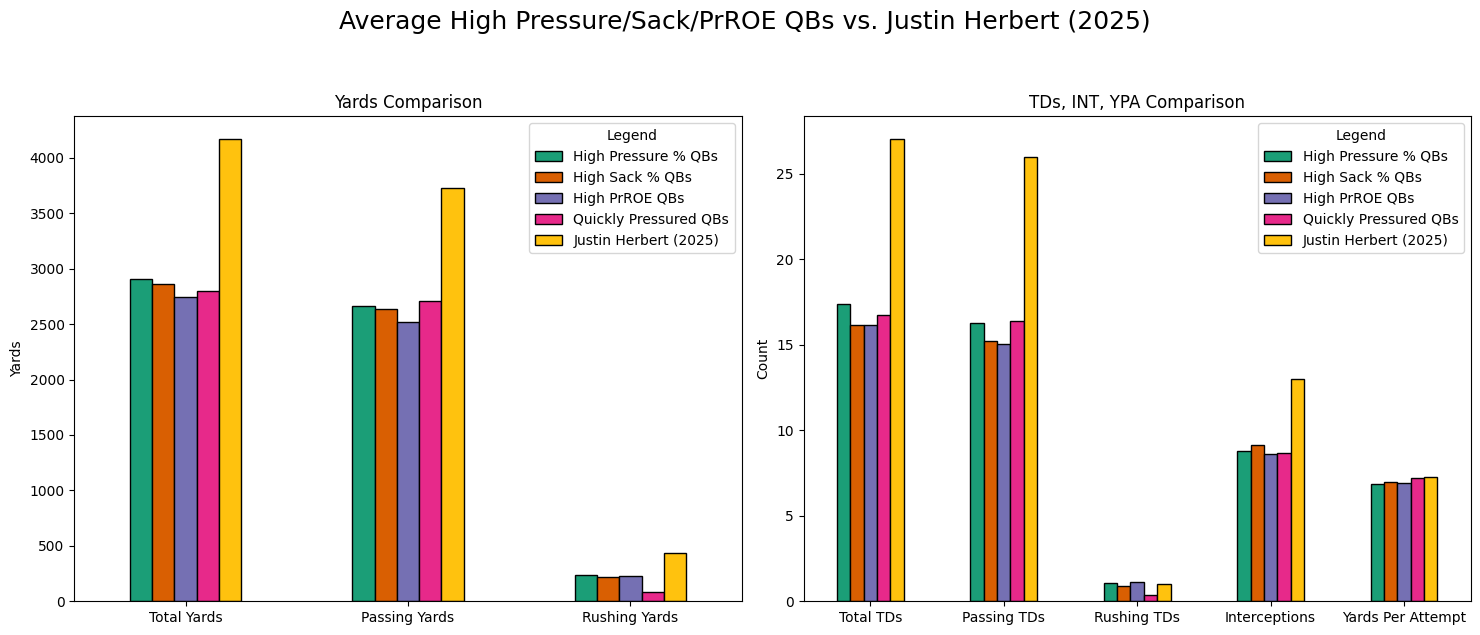

In [46]:
#make a column chart of all the high pressure, sack, and PrROE QBs counting stats to compare them to Justin Herbert
Average_Pressured_QBs_Counting_Stats_Comp_w_Herbert = pd.DataFrame({
    'High Pressure % QBs': High_Pressure_Percentage_QBs_Average_Counting_Stats,
    'High Sack % QBs': High_Sack_Percentage_QBs_Average_Counting_Stats,
    'High PrROE QBs': High_PrROE_QBs_Average_Counting_Stats,
    'Quickly Pressured QBs': Quickly_Pressured_QBs_Average_Counting_Stats,
    'Justin Herbert (2025)': Justin_Herbert_2025_Counting_Stats.iloc[0]
})

#define the metrics that will go on each plot
yards_metrics = ['Total_Yards', 'P_YDS', 'R_YDS']
tds_int_ypa_metrics = ['Total_TDs', 'P_TDs', 'R_TDs', 'INT', 'YPA']

#create subplots for (1 row, 2 columns  
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
#yards plot
Average_Pressured_QBs_Counting_Stats_Comp_w_Herbert.loc[yards_metrics].plot(kind='bar', ax=axes[0], color=['#1B9E77', '#D95F02', '#7570B3', '#E7298A', '#FFC20E'], edgecolor='black')
axes[0].set_title('Yards Comparison')  
axes[0].set_ylabel('Yards')
axes[0].set_xticklabels(['Total Yards', 'Passing Yards', 'Rushing Yards'], rotation=0, ha='center')
axes[0].legend(title='Legend', loc='upper right')
#tds_int_ypa_metrics plot
Average_Pressured_QBs_Counting_Stats_Comp_w_Herbert.loc[tds_int_ypa_metrics].plot(kind='bar', ax=axes[1], color=['#1B9E77', '#D95F02', '#7570B3', '#E7298A', '#FFC20E'], edgecolor='black')
axes[1].set_title('TDs, INT, YPA Comparison')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Total TDs', 'Passing TDs', 'Rushing TDs', 'Interceptions', 'Yards Per Attempt'], rotation=0, ha='center')
axes[1].legend(title='Legend', loc='upper right')
# Final formatting
plt.suptitle('Average High Pressure/Sack/PrROE QBs vs. Justin Herbert (2025)', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [47]:
#now let's get the average of those average stats to get an exact difference between how Herbert did compared to them
Average_of_High_Pressured_QBs_Counting_Stats = Average_Pressured_QBs_Counting_Stats_Comp_w_Herbert[['High Pressure % QBs', 'High Sack % QBs', 'High PrROE QBs', 'Quickly Pressured QBs']].mean(axis=1)
Average_of_High_Pressured_QBs_Counting_Stats

P_YDS            2632.842086
YDS/G             203.254566
P_TDs              15.732522
INT                 8.804791
YPA                 6.980267
ATT               374.303835
R_YDS             193.471475
R_TDs               0.872514
Total_Yards      2826.313560
Total_TDs          16.605036
P_TDs_Per_Att       0.040812
dtype: float64

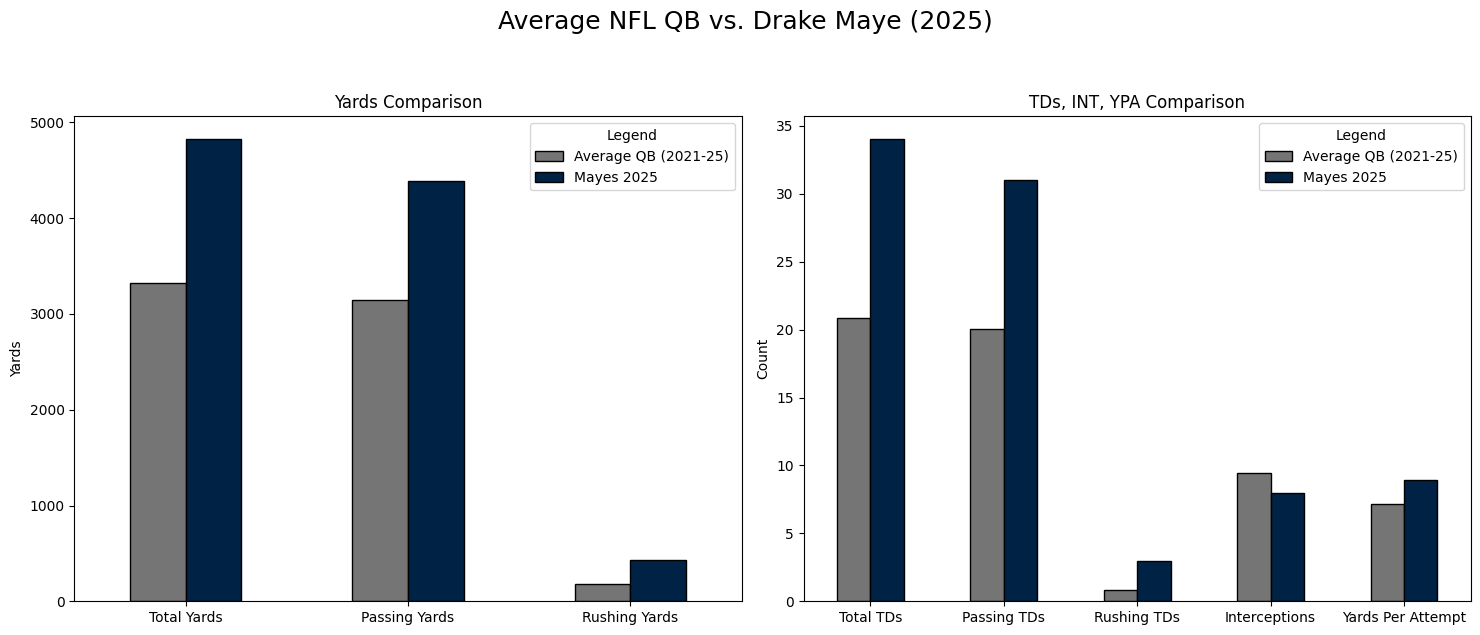

In [52]:
#now compare the average NFL QB over the last 5 years to Mayes 2025 season
Average_QB_vs_Maye_Comp_df = pd.DataFrame({
    'Average QB (2021-25)': Ave_QB_Stats,
    'Mayes 2025': Drake_Maye_2025_Counting_Stats.iloc[0]
})

#define the metrics that will go on each plot
yards_metrics = ['Total_Yards', 'P_YDS', 'R_YDS']
tds_int_ypa_metrics = ['Total_TDs', 'P_TDs', 'R_TDs', 'INT', 'YPA']

#create subplots for (1 row, 2 columns  
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
#yards plot
Average_QB_vs_Maye_Comp_df.loc[yards_metrics].plot(kind='bar', ax=axes[0], color=['#757575', '#002244'], edgecolor='black')
axes[0].set_title('Yards Comparison')   
axes[0].set_ylabel('Yards')
axes[0].set_xticklabels(['Total Yards', 'Passing Yards', 'Rushing Yards'], rotation=0, ha='center')
axes[0].legend(title='Legend', loc='upper right')
#tds_int_ypa_metrics plot
Average_QB_vs_Maye_Comp_df.loc[tds_int_ypa_metrics].plot(kind='bar', ax=axes[1], color=['#757575', '#002244'], edgecolor='black')
axes[1].set_title('TDs, INT, YPA Comparison')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Total TDs', 'Passing TDs', 'Rushing TDs', 'Interceptions', 'Yards Per Attempt'], rotation=0, ha='center')
axes[1].legend(title='Legend', loc='upper right')
# Final formatting
plt.suptitle('Average NFL QB vs. Drake Maye (2025)', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [54]:
#calculate the numerical difference between Herbert's 2025 season and the average of the highly pressured/sacked/PrROE QBs to see how much better or worse he did compared to them
Herbert_vs_Highly_Pressured_QBs_Difference = Justin_Herbert_2025_Counting_Stats.iloc[0] - Average_of_High_Pressured_QBs_Counting_Stats
Herbert_vs_Highly_Pressured_QBs_Difference

P_YDS            1094.157914
YDS/G              29.645434
P_TDs              10.267478
INT                 4.195209
YPA                 0.299733
ATT               137.696165
R_YDS             245.528525
R_TDs               0.127486
Total_Yards      1339.686440
Total_TDs          10.394964
P_TDs_Per_Att       0.009969
dtype: float64

In [55]:
#calculate the difference between Mayes 2025 season and the average NFL QB to see how much better or worse he did compared to the average QB
Maye_vs_Average_QB_Difference = Drake_Maye_2025_Counting_Stats.iloc[0] - Ave_QB_Stats
Maye_vs_Average_QB_Difference

P_YDS            1250.176136
YDS/G              35.235795
P_TDs              10.982955
INT                -1.448864
YPA                 1.801023
ATT                53.948864
R_YDS             250.409091
R_TDs               2.159091
Total_Yards      1500.585227
Total_TDs          13.142045
P_TDs_Per_Att       0.018607
dtype: float64

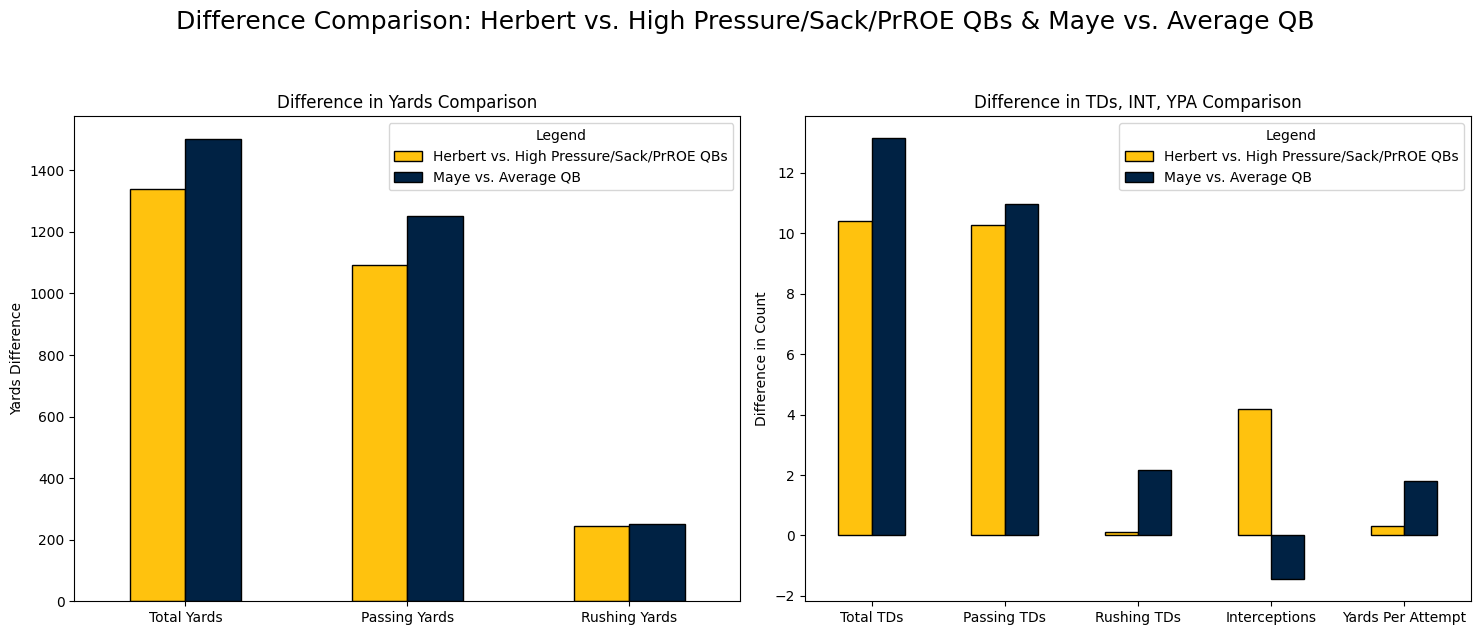

In [56]:
#plot the differences between Herbert vs. the highly pressured/sacked/PrROE QBs and Maye vs. the average QB
Difference_Comp_df = pd.DataFrame({
    'Herbert vs. High Pressure/Sack/PrROE QBs': Herbert_vs_Highly_Pressured_QBs_Difference,
    'Maye vs. Average QB': Maye_vs_Average_QB_Difference
})

#define the metrics that will go on each plot
yards_metrics = ['Total_Yards', 'P_YDS', 'R_YDS']
tds_int_ypa_metrics = ['Total_TDs', 'P_TDs', 'R_TDs', 'INT', 'YPA']
#create subplots for (1 row, 2 columns  
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
#yards plot
Difference_Comp_df.loc[yards_metrics].plot(kind='bar', ax=axes[0], color=['#FFC20E', '#002244'], edgecolor='black')
axes[0].set_title('Difference in Yards Comparison') 
axes[0].set_ylabel('Yards Difference')
axes[0].set_xticklabels(['Total Yards', 'Passing Yards', 'Rushing Yards'], rotation=0, ha='center')
axes[0].legend(title='Legend', loc='upper right')   
#tds_int_ypa_metrics plot
Difference_Comp_df.loc[tds_int_ypa_metrics].plot(kind='bar', ax=axes[1], color=['#FFC20E', '#002244'], edgecolor='black')
axes[1].set_title('Difference in TDs, INT, YPA Comparison')
axes[1].set_ylabel('Difference in Count')
axes[1].set_xticklabels(['Total TDs', 'Passing TDs', 'Rushing TDs', 'Interceptions', 'Yards Per Attempt'], rotation=0, ha='center')
axes[1].legend(title='Legend', loc='upper right')
# Final formatting
plt.suptitle('Difference Comparison: Herbert vs. High Pressure/Sack/PrROE QBs & Maye vs. Average QB', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [67]:
#what if Drake Maye's season is removed from the highly pressured/sacked/PrROE QBs category, how would that change the average stats for those categories and how would that change the difference between Herbert and those categories
#remove Maye's 2025 season from each of the highly pressured/sacked/PrROE QBs categories
High_Pressure_Percentage_QBs_Without_Maye = High_Pressure_Percentage_QBs[High_Pressure_Percentage_QBs['Name'] != 'Drake Maye'].copy()
High_Sack_Percentage_QBs_Without_Maye = High_Sack_Percentage_QBs[High_Sack_Percentage_QBs['Name'] != 'Drake Maye'].copy()
High_PrROE_QBs_Without_Maye = High_PrROE_QBs[High_PrROE_QBs['Name'] != 'Drake Maye'].copy()

#get the average counting stats for the highly pressured/sacked/PrROE QBs without Maye
High_Pressure_Percentage_QBs_Without_Maye_Counting_Stats = High_Pressure_Percentage_QBs_Without_Maye[['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()
High_Pressure_Percentage_QBs_Without_Maye_Average_Counting_Stats = High_Pressure_Percentage_QBs_Without_Maye_Counting_Stats.mean()
   
High_Sack_Percentage_QBs_Without_Maye_Counting_Stats = High_Sack_Percentage_QBs_Without_Maye[['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()   
High_Sack_Percentage_QBs_Without_Maye_Average_Counting_Stats = High_Sack_Percentage_QBs_Without_Maye_Counting_Stats.mean()

High_PrROE_QBs_Without_Maye_Counting_Stats = High_PrROE_QBs_Without_Maye[['P_YDS', 'YDS/G','P_TDs', 'INT', 'YPA', 
                                                                'ATT', 'R_YDS', 'R_TDs', 'Total_Yards', 'Total_TDs', 'P_TDs_Per_Att']].copy()   
High_PrROE_QBs_Without_Maye_Average_Counting_Stats = High_PrROE_QBs_Without_Maye_Counting_Stats.mean()

#now let's get the average of those average stats to get an exact difference between how Herbert did compared to them without Maye
Average_of_High_Pressured_QBs_Without_Maye_Counting_Stats = pd.DataFrame({
    'High Pressure % QBs without Maye': High_Pressure_Percentage_QBs_Without_Maye_Average_Counting_Stats,
    'High Sack % QBs without Maye': High_Sack_Percentage_QBs_Without_Maye_Average_Counting_Stats,
    'High PrROE QBs without Maye': High_PrROE_QBs_Without_Maye_Average_Counting_Stats
}).mean(axis=1)

Average_of_High_Pressured_QBs_Without_Maye_Counting_Stats

P_YDS            2568.528322
YDS/G             197.258279
P_TDs              15.102614
INT                 8.848366
YPA                 6.846505
ATT               373.010022
R_YDS             218.827015
R_TDs               0.967756
Total_Yards      2787.355338
Total_TDs          16.070370
P_TDs_Per_Att       0.039510
dtype: float64

In [33]:
#get data for a rushing compariison chart between the RBs on the Patriots and the Chargers in 2025
file = "C:\\Users\\SpeeJ\\OneDrive\\Desktop\\Fantasy_Points_Data\\Patriots_vs_Chargers_RB_Data_2025\\Patriots_vs_Chargers_Main_RB_Stats_2025.csv"
Patriots_vs_Chargers_Main_RB_Data_2025 = pd.read_csv(file)

Patriots_vs_Chargers_Main_RB_Data = Patriots_vs_Chargers_Main_RB_Data_2025[['Name', 'Team','ATT','YDS', 'YPC', 'TD', 'EXP RUN %', 'Success %', 'STUFF %', 'MTF', 'MTF/ATT', 'YACO', 'YACO/ATT', 'YBCO/ATT']].copy()
Patriots_vs_Chargers_Main_RB_Data['YBCO'] = Patriots_vs_Chargers_Main_RB_Data['YBCO/ATT'] * Patriots_vs_Chargers_Main_RB_Data['ATT']

Patriots_vs_Chargers_Main_RB_Data

,Name,Team,ATT,YDS,YPC,TD,EXP RUN %,Success %,STUFF %,MTF,MTF/ATT,YACO,YACO/ATT,YBCO/ATT,YBCO
0,Rhamondre Stevenson,NE,130,603,4.64,7,6.9,50.8,48.5,30,0.23,358,2.75,1.88,244.40
1,Omarion Hampton,LAC,124,545,4.40,4,6.5,46.8,48.4,21,0.17,275,2.22,2.18,270.32
2,TreVeyon Henderson,NE,180,911,5.06,9,5.6,51.1,47.2,24,0.13,343,1.91,3.16,568.80
3,Kimani Vidal,LAC,155,643,4.15,3,3.9,47.1,52.3,20,0.13,311,2.01,2.14,331.70


In [34]:
Patriots_vs_Chargers_Main_RB_Data = Patriots_vs_Chargers_Main_RB_Data.groupby('Team')[['ATT','YDS', 'TD', 'MTF', 'YACO', 'YBCO']].sum().reset_index()
Patriots_vs_Chargers_Main_RB_Data['YPC'] = Patriots_vs_Chargers_Main_RB_Data['YDS'] / Patriots_vs_Chargers_Main_RB_Data['ATT']
Patriots_vs_Chargers_Main_RB_Data['MTF/ATT'] = Patriots_vs_Chargers_Main_RB_Data['MTF'] / Patriots_vs_Chargers_Main_RB_Data['ATT']
Patriots_vs_Chargers_Main_RB_Data['YACO/ATT'] = Patriots_vs_Chargers_Main_RB_Data['YACO'] / Patriots_vs_Chargers_Main_RB_Data['ATT']
Patriots_vs_Chargers_Main_RB_Data['YBCO/ATT'] = Patriots_vs_Chargers_Main_RB_Data['YBCO'] / Patriots_vs_Chargers_Main_RB_Data['ATT']
Patriots_vs_Chargers_Main_RB_Data['TD/ATT'] = Patriots_vs_Chargers_Main_RB_Data['TD'] / Patriots_vs_Chargers_Main_RB_Data['ATT']
Patriots_vs_Chargers_Main_RB_Data

,Team,ATT,YDS,TD,MTF,YACO,YBCO,YPC,MTF/ATT,YACO/ATT,YBCO/ATT,TD/ATT
0,LAC,279,1188,7,41,586,602.02,4.258065,0.146953,2.100358,2.157778,0.025090
1,NE,310,1514,16,54,701,813.20,4.883871,0.174194,2.261290,2.623226,0.051613


In [35]:
#get data for a rushing compariison chart between the RBs on the Patriots and the Chargers in 2025
file = "C:\\Users\\SpeeJ\\OneDrive\\Desktop\\Fantasy_Points_Data\\Patriots_vs_Chargers_RB_Data_2025\\Patriots_vs_Chargers_All_RB_Stats_2025.csv"
Patriots_vs_Chargers_All_RB_Data_2025 = pd.read_csv(file)

Patriots_vs_Chargers_All_RB_Data = Patriots_vs_Chargers_All_RB_Data_2025[['Name', 'Team','ATT','YDS', 'YPC', 'TD', 'EXP RUN %', 'Success %', 'STUFF %', 'MTF', 'MTF/ATT', 'YACO', 'YACO/ATT', 'YBCO/ATT']].copy()
Patriots_vs_Chargers_All_RB_Data['YBCO'] = Patriots_vs_Chargers_All_RB_Data['YBCO/ATT'] * Patriots_vs_Chargers_All_RB_Data['ATT']

Patriots_vs_Chargers_All_RB_Data

,Name,Team,ATT,YDS,YPC,TD,EXP RUN %,Success %,STUFF %,MTF,MTF/ATT,YACO,YACO/ATT,YBCO/ATT,YBCO
0,Antonio Gibson,NE,25,106,4.24,1,8.0,44.0,56.0,1,0.04,64,2.56,1.68,42.00
1,Rhamondre Stevenson,NE,130,603,4.64,7,6.9,50.8,48.5,30,0.23,358,2.75,1.88,244.40
2,Omarion Hampton,LAC,124,545,4.40,4,6.5,46.8,48.4,21,0.17,275,2.22,2.18,270.32
3,TreVeyon Henderson,NE,180,911,5.06,9,5.6,51.1,47.2,24,0.13,343,1.91,3.16,568.80
4,Kimani Vidal,LAC,155,643,4.15,3,3.9,47.1,52.3,20,0.13,311,2.01,2.14,331.70
5,Jaret Patterson,LAC,41,159,3.88,1,2.4,48.8,51.2,6,0.15,92,2.24,1.63,66.83
6,Terrell Jennings,NE,23,73,3.17,1,NaN,43.5,56.5,1,0.04,42,1.83,1.35,31.05
7,Najee Harris,LAC,15,61,4.07,0,NaN,86.7,13.3,1,0.07,50,3.33,0.73,10.95
8,Hassan Haskins,LAC,17,47,2.76,0,NaN,29.4,70.6,1,0.06,27,1.59,1.18,20.06
9,Amar Johnson,LAC,2,8,4.00,0,NaN,50.0,50.0,0,NaN,4,2.00,2.00,4.00


In [36]:
Patriots_vs_Chargers_All_RB_Data = Patriots_vs_Chargers_All_RB_Data.groupby('Team')[['ATT','YDS', 'TD', 'MTF', 'YACO', 'YBCO']].sum().reset_index()
Patriots_vs_Chargers_All_RB_Data['YPC'] = Patriots_vs_Chargers_All_RB_Data['YDS'] / Patriots_vs_Chargers_All_RB_Data['ATT']
Patriots_vs_Chargers_All_RB_Data['MTF/ATT'] = Patriots_vs_Chargers_All_RB_Data['MTF'] / Patriots_vs_Chargers_All_RB_Data['ATT']
Patriots_vs_Chargers_All_RB_Data['YACO/ATT'] = Patriots_vs_Chargers_All_RB_Data['YACO'] / Patriots_vs_Chargers_All_RB_Data['ATT']
Patriots_vs_Chargers_All_RB_Data['YBCO/ATT'] = Patriots_vs_Chargers_All_RB_Data['YBCO'] / Patriots_vs_Chargers_All_RB_Data['ATT']
Patriots_vs_Chargers_All_RB_Data

,Team,ATT,YDS,TD,MTF,YACO,YBCO,YPC,MTF/ATT,YACO/ATT,YBCO/ATT
0,LAC,354,1463,8,49,759,703.86,4.132768,0.138418,2.144068,1.988305
1,NE,358,1693,18,56,807,886.25,4.729050,0.156425,2.254190,2.475559


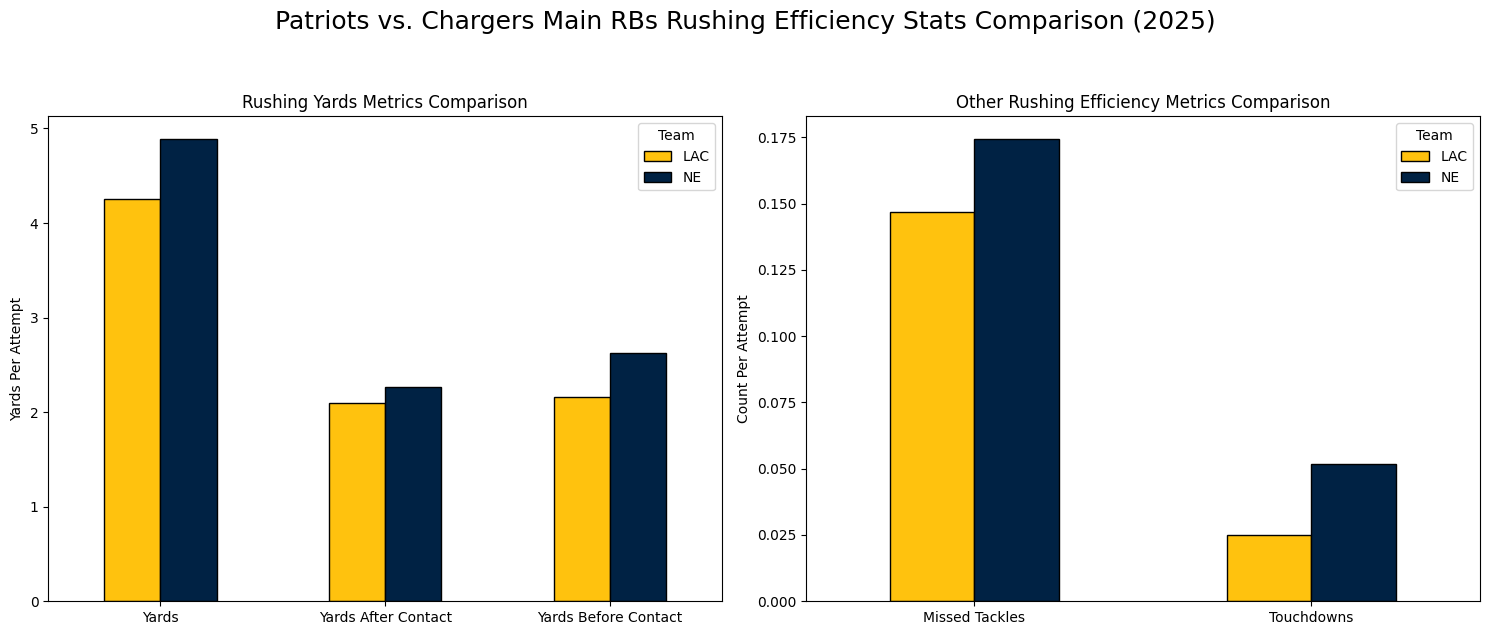

In [74]:
#creae another column chart to compare the rushing stats of the RBs on the Patriots and the Chargers in 2025
Patriots_vs_Chargers_Main_RB_Data_Chart = Patriots_vs_Chargers_Main_RB_Data[['Team', 'YPC', 'MTF/ATT', 'YACO/ATT', 'YBCO/ATT', 'TD/ATT']]

#define the metrics that will go on the plot
rushing_yards_metrics = ['YPC', 'YACO/ATT', 'YBCO/ATT']
other_rushing_efficiency_metrics = ['MTF/ATT', 'TD/ATT']

#set team as the index for the dataframes
rushing_yards_metrics_df = Patriots_vs_Chargers_Main_RB_Data_Chart.set_index('Team')[rushing_yards_metrics].T
other_rushing_efficiency_metrics_df = Patriots_vs_Chargers_Main_RB_Data_Chart.set_index('Team')[other_rushing_efficiency_metrics].T

#set colors for the plots
colors = ['#FFC20E', '#002244']

#create the figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#rushing yards metrics plot
rushing_yards_metrics_df.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Rushing Yards Metrics Comparison') 
axes[0].set_ylabel('Yards Per Attempt')
axes[0].set_xticklabels(['Yards', 'Yards After Contact', 'Yards Before Contact'], rotation=0, ha='center')
axes[0].legend(title='Team', loc='upper right')   
#other rushing efficiency metrics plot
other_rushing_efficiency_metrics_df.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Other Rushing Efficiency Metrics Comparison')
axes[1].set_ylabel('Count Per Attempt')
axes[1].set_xticklabels(['Missed Tackles', 'Touchdowns'], rotation=0, ha='center')
axes[1].legend(title='Team', loc='upper right')
# Final formatting
plt.suptitle('Patriots vs. Chargers Main RBs Rushing Efficiency Stats Comparison (2025)', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

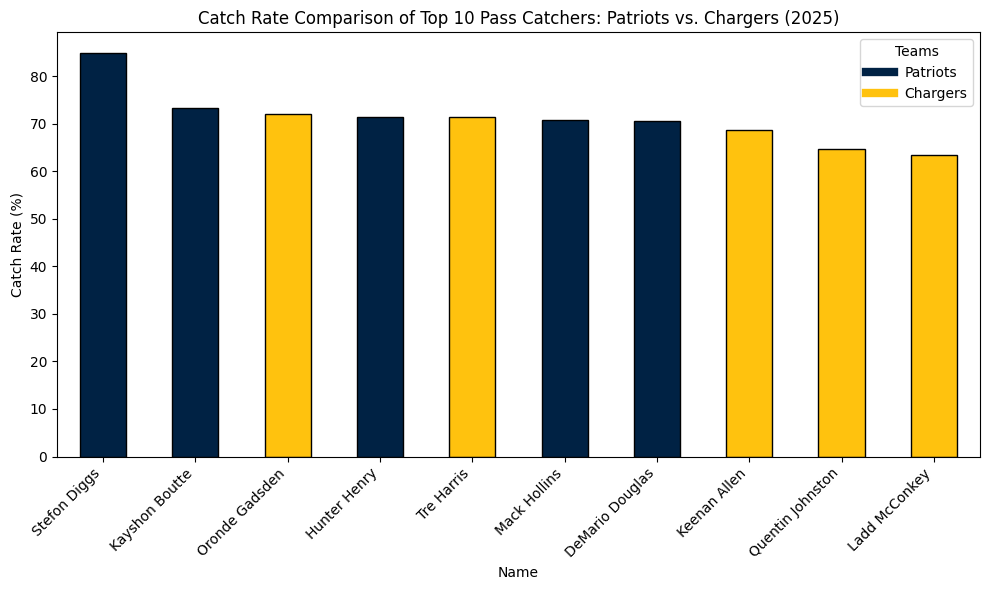

In [66]:
#get data for a pass catcher compariison chart between the Patriots and the Chargers in 2025
file = "C:\\Users\\SpeeJ\\OneDrive\\Desktop\\Fantasy_Points_Data\\Patriots_vs_Chargers_Pass_Catcher_Data_2025\\Patriots_vs_Chargers_Top_10_Pass_Catchers_Data_2025.csv"
Patriots_vs_Chargers_Top_10_Pass_Catchers_Data_2025 = pd.read_csv(file)

Patriots_vs_Chargers_Top_10_Pass_Catchers_Chart_Data = Patriots_vs_Chargers_Top_10_Pass_Catchers_Data_2025[['Name', 'Team', 'CR %']].copy()
Patriots_vs_Chargers_Top_10_Pass_Catchers_Chart_Data = Patriots_vs_Chargers_Top_10_Pass_Catchers_Chart_Data.sort_values(by='CR %', ascending=False).reset_index(drop=True)

#make a column chart to compare the catch rates of the top 10 pass catchers on the Patriots and the Chargers in 2025
fig, ax = plt.subplots(figsize=(10, 6))

#map colors based on team affiliation
colors = Patriots_vs_Chargers_Top_10_Pass_Catchers_Chart_Data['Team'].map({'LAC': '#FFC20E', 'NE': '#002244'})

#plot the bar chart with the mapped colors
Patriots_vs_Chargers_Top_10_Pass_Catchers_Chart_Data.plot(kind='bar', x='Name', y='CR %', ax=ax, color=colors, edgecolor='black')

#formatting
ax.set_title('Catch Rate Comparison of Top 10 Pass Catchers: Patriots vs. Chargers (2025)')
ax.set_ylabel('Catch Rate (%)')
ax.set_xticklabels(Patriots_vs_Chargers_Top_10_Pass_Catchers_Chart_Data['Name'], rotation=45, ha='right')

#legend formatting
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#002244', lw=6, label='Patriots'),
    Line2D([0], [0], color='#FFC20E', lw=6, label='Chargers')
]
ax.legend(handles=legend_elements, title='Teams', loc='upper right')

plt.tight_layout()
plt.show()